In [2]:
# ! pip install pandas numpy matplotlib scikit-learn scipy cartopy geopy shapely

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import re
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from geopy.distance import geodesic
from geopy import Point
import cartopy.crs as ccrs
from shapely.geometry import LineString, Point as ShapelyPoint, Polygon
from shapely.ops import substring

In [4]:
#Insert here your seismic source parameters [globalcmt.org]
#2010 Maule earthquake
earthquake = {
    'event': '2010 Maule earthquake',
    'latitude': -35.98,
    'longitude': -73.15,
    'depth_km': 23.2,
    'Mw': 8.8,
    'scalar_moment_Nm': 1.86e+29,  # скалярный момент в Н * м
    'strike_deg': 19, # азимут
    'dip_deg': 18, # угол падения
    'rake_deg': 116 # разворот 
}

In [5]:
#Calculating size of rupture using Riznichenko formulae
earthquake['length'] = 10 ** ( 0.440*earthquake['Mw'] -1.289 )
earthquake['width'] = 10 ** ( 0.401*earthquake['Mw'] -1.448 )

print(f"{earthquake['event']} located at ({earthquake['latitude']}°N, {earthquake['longitude']}°E), "
      f"Mw={earthquake['Mw']}, depth={earthquake['depth_km']} km, source length={earthquake['length']} km, source_width={earthquake['width']} km")

2010 Maule earthquake located at (-35.98°N, -73.15°E), Mw=8.8, depth=23.2 km, source length=382.82474331682283 km, source_width=120.44811285731771 km


In [6]:
# Load the uploaded CSV file
file_path = '../data/NEIC_Global_1900_2025.csv'
df = pd.read_csv(file_path)
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,NaN,NaN,NaN,NaN,...,2025-04-18T00:16:56.005Z,"Southern Sumatra, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,NaN,NaN,NaN,NaN,...,2025-04-18T22:55:15.621Z,Bismarck Sea,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,NaN,NaN,NaN,NaN,...,2025-04-19T23:36:34.400Z,"Jalisco, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
3,1900-01-31T19:22:00.000Z,48.0,146.0,450.0,7.5,mj,NaN,NaN,NaN,NaN,...,2025-04-26T21:47:57.256Z,Sea of Okhotsk,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent
4,1900-04-30T22:41:14.000Z,36.9,-121.6,NaN,4.5,ml,NaN,NaN,NaN,NaN,...,2023-12-04T00:47:36.941Z,"Near Aromas, California",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,cdmg


In [7]:
# Select only the required columns
final_df = df[['latitude', 'longitude', 'depth', 'mag']]

#Filter initial seismic catalog to get earthquakes with magnitudes exceed threshold
mag_threshold = 4.5
final_df = final_df[final_df['mag'] > mag_threshold]

#Cleaning data from NaNs
final_df_clean = final_df.dropna().reset_index(drop=True, inplace=False)

# Display first few rows of the cleaned dataframe
final_df_clean.head()

,latitude,longitude,depth,mag
0,48.0,146.0,450.0,7.50
1,38.7,141.1,5.0,7.00
2,57.4,-151.0,20.0,7.86
3,43.5,148.0,35.0,7.00
4,43.0,146.0,35.0,7.10


In [8]:
#Reading lithospheric plate bounadries for NNR-MORVEL56 model [Argus et al., 2011]
file_path = '../data/All_boundaries'

latitudes = []
longitudes = []

with open(file_path, 'r') as file:
    for line in file:
        if not line.startswith(' '):
            continue  # skip comment lines without leading spaces
        try:
            parts = line.strip().split()
            if len(parts) != 2:
                print(f"Skipping malformed line: {line.strip()}")
                continue
            lat, lon = map(float, parts)
            latitudes.append(lat)
            longitudes.append(lon)
        except Exception as e:
            print(f"Error parsing line '{line.strip()}': {e}")

# Create DataFrame
boundaries_df = pd.DataFrame({
    'latitude': latitudes,
    'longitude': longitudes
})

print(boundaries_df.head())

   latitude  longitude
0   -54.852     -0.438
1   -54.677     -0.039
2   -54.451      0.443
3   -54.832      0.965
4   -54.399      1.695


In [9]:
#Calculating geographic area for catalog search
#Making boundary points in strike direction

# Half-length distance
half_length = earthquake['length'] / 2  # in km

# Starting point (epicenter)
epicenter = Point(earthquake['latitude'], earthquake['longitude'])

# Point in strike direction
point_forward = geodesic(kilometers=half_length).destination(epicenter, earthquake['strike_deg'])

# Point in opposite strike direction (+180°)
point_backward = geodesic(kilometers=half_length).destination(epicenter, (earthquake['strike_deg'] + 180) % 360)

print(f"Point forward (along strike): lat={point_forward.latitude}, lon={point_forward.longitude}")
print(f"Point backward (opposite strike): lat={point_backward.latitude}, lon={point_backward.longitude}")

Point forward (along strike): lat=-34.346760194973996, lon=-72.47277567017099
Point backward (opposite strike): lat=-37.60881253553208, lon=-73.85568651113753


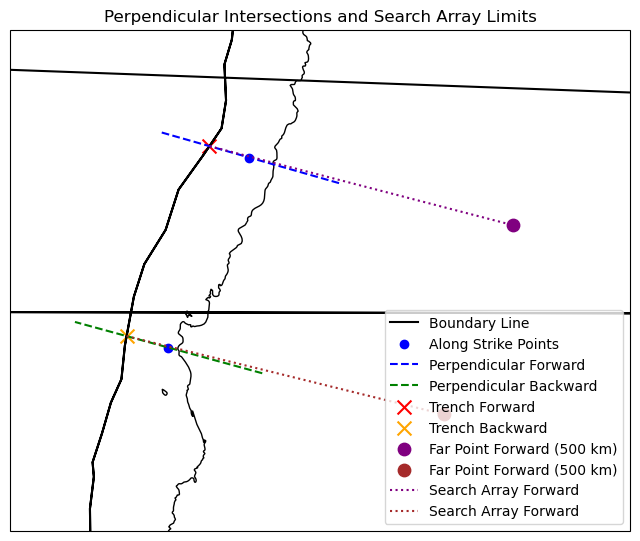

In [10]:
#Finding closest boundary(trench) and calculating intersect points

# Step 1: Boundary line from DataFrame
line = LineString(zip(boundaries_df['longitude'], boundaries_df['latitude']))

# -------- Perpendicular Line Construction ---------
def build_perpendicular_line(start_point, strike, length=150):
    az1 = (strike + 90) % 360
    az2 = (strike - 90) % 360
    p1 = geodesic(kilometers=length).destination(start_point, az1)
    p2 = geodesic(kilometers=length).destination(start_point, az2)
    return LineString([(p1.longitude, p1.latitude), (p2.longitude, p2.latitude)])

perp_line_forward = build_perpendicular_line(point_forward, earthquake['strike_deg'])
perp_line_backward = build_perpendicular_line(point_backward, earthquake['strike_deg'])

# -------- Intersection with boundary ---------
def project_intersection(perp_line, boundary_line):
    intersection = perp_line.intersection(boundary_line)
    if intersection.is_empty:
        return None, None
    if intersection.geom_type == 'Point':
        return intersection.y, intersection.x
    elif intersection.geom_type == 'MultiPoint':
        point = list(intersection)[0]
        return point.y, point.x
    else:
        return None, None

p1_lat, p1_lon = project_intersection(perp_line_forward, line)
p2_lat, p2_lon = project_intersection(perp_line_backward, line)

# Create Shapely Points for p1 and p2
p1_geom = ShapelyPoint(p1_lon, p1_lat)
p2_geom = ShapelyPoint(p2_lon, p2_lat)

# Project points onto the boundary line (returns distance along the line)
distance_p1 = line.project(p1_geom)
distance_p2 = line.project(p2_geom)

# Ensure proper order (from p1 to p2 along the boundary line)
start_distance = min(distance_p1, distance_p2)
end_distance = max(distance_p1, distance_p2)

# Extract the subsection of the boundary line (which is closest to the source)
sub_boundary = substring(line, start_distance, end_distance)

# Optional: Extract lat/lon coordinates
sub_lon, sub_lat = sub_boundary.xy

# -------- Compute far points 500 km from intersection ---------
def point_along_direction(lat, lon, azimuth, distance_km):
    start = Point(lat, lon)
    dest = geodesic(kilometers=distance_km).destination(start, azimuth)
    return dest.latitude, dest.longitude

def calculate_far_point(inter_lat, inter_lon, strike, direction): # strike не используется!!!
    azimuth = (strike + 90) % 360 if direction == 'forward' else (strike - 90) % 360 # исправлено
    far_lat, far_lon = point_along_direction(inter_lat, inter_lon, azimuth, 500)
    return far_lat, far_lon

far1_lat, far1_lon = calculate_far_point(p1_lat, p1_lon, earthquake['strike_deg'], 'forward')
far2_lat, far2_lon = calculate_far_point(p2_lat, p2_lon, earthquake['strike_deg'], 'forward')

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Forward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Forward')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower right')
ax.set_title('Perpendicular Intersections and Search Array Limits')
plt.show;

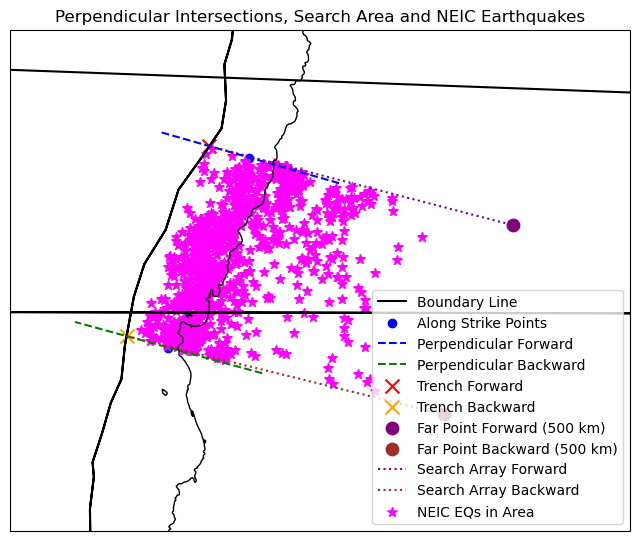

In [11]:
# -------- Define polygon for earthquake catalog search---------
search_polygon = Polygon([
    (p1_lon, p1_lat),
    (far1_lon, far1_lat),
    (far2_lon, far2_lat),
    (p2_lon, p2_lat),
    (p1_lon, p1_lat)
])

# Filter earthquakes inside the search polygon
def is_inside(lat, lon):
    return search_polygon.contains(ShapelyPoint(lon, lat))

final_df['inside_polygon'] = final_df.apply(lambda row: is_inside(row['latitude'], row['longitude']), axis=1)
selected_eq = final_df[final_df['inside_polygon']]

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Backward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Backward')

# Earthquakes inside polygon
ax.scatter(selected_eq['longitude'], selected_eq['latitude'], color='magenta', marker='*', s=50, label='NEIC EQs in Area')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower right')
ax.set_title('Perpendicular Intersections, Search Area and NEIC Earthquakes')
plt.show()

In [12]:
# -------- Distance to Boundary Calculation ---------
def distance_to_boundary(lat, lon, boundary_line):
    point_geom = ShapelyPoint(lon, lat)
    nearest_point = boundary_line.interpolate(boundary_line.project(point_geom))
    distance = geodesic((lat, lon), (nearest_point.y, nearest_point.x)).km
    return distance

# DataFrame with depth and distance from boundary
depth_distance_df = selected_eq.copy()
depth_distance_df['depth'] = -np.abs(depth_distance_df['depth'])
depth_distance_df['distance'] = depth_distance_df.apply(
    lambda row: distance_to_boundary(row['latitude'], row['longitude'], sub_boundary), axis=1
)
depth_distance_df = depth_distance_df[['depth', 'distance', 'mag']]
depth_distance_df.reset_index(drop=True, inplace=True)
depth_distance_df.head(20)

,depth,distance,mag
0,-15.0,22.140427,7.69
1,-35.0,140.633854,6.05
2,-35.0,136.365081,6.07
3,-35.0,124.063120,7.70
4,-35.0,77.975264,6.02
5,-35.0,131.981199,6.17
6,-30.0,105.990911,7.23
7,-35.0,91.237268,5.52
8,-35.0,131.321274,5.27
9,-35.0,124.857736,5.48


In [13]:
depth_distance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   depth     993 non-null    float64
 1   distance  993 non-null    float64
 2   mag       993 non-null    float64
dtypes: float64(3)
memory usage: 23.4 KB


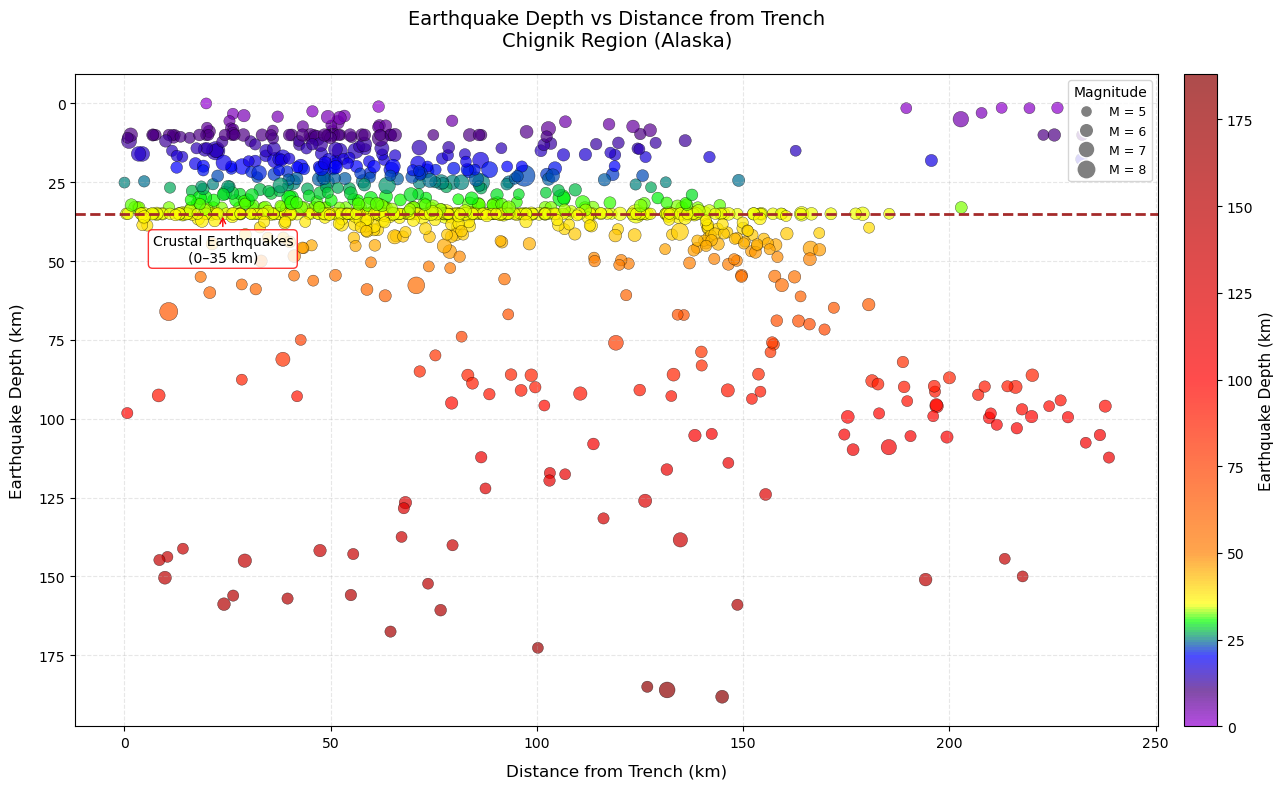

In [ ]:
# Visualization of source data
 
max_depth = depth_distance_df['depth'].abs().max()

depth_segments = [
    (0.0, '#9400D3'),
    (10/max_depth, '#4B0082'), 
    (20/max_depth, '#0000FF'), 
    (30/max_depth, '#00FF00'), 
    (35/max_depth, '#FFFF00'),
    (50/max_depth, '#FF7F00'),
    (100/max_depth if 100/max_depth <= 1.0 else 1.0, '#FF0000'), 
    (1.0, '#8B0000')
]

cmap_depth = LinearSegmentedColormap.from_list('depth_cmap', depth_segments)

plt.figure(figsize=(14, 8))

positive_depths = -depth_distance_df['depth']

scatter = plt.scatter(
    depth_distance_df['distance'],
    positive_depths,
    c=positive_depths,
    s=depth_distance_df['mag']**2 * 3,
    cmap=cmap_depth,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    vmin=0,
    vmax=max_depth
)

ax = plt.gca()
ax.invert_yaxis()

plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')

plt.title('Earthquake Depth vs Distance from Trench\nChignik Region (Alaska)', fontsize=14, pad=20)
plt.xlabel('Distance from Trench (km)', fontsize=12, labelpad=10)
plt.ylabel('Earthquake Depth (km)', fontsize=12, labelpad=10)
plt.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Earthquake Depth (km)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# Magnitude legend
mag_sizes = [2, 4, 6, 8]
legend_elements = []
for mag in mag_sizes:
    legend_elements.append(
        plt.Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=f'M = {mag}',
                   markerfacecolor='gray', 
                   markersize=np.sqrt(mag**2 * 3))
    )
plt.legend(handles=legend_elements, title='Magnitude', loc='upper right', frameon=True, fontsize=9)

# Inscription for crustal earthquakes
max_dist = max(depth_distance_df['distance'])
plt.annotate('Crustal Earthquakes\n(0–35 km)', 
             xy=(max_dist * 0.1, 35),
             xytext=(max_dist * 0.1, 50),
             arrowprops=dict(arrowstyle='->', color='red'),
             ha='center', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8),
             fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
depth_frequency = depth_distance_df['depth'].value_counts()

frequent_depths = depth_frequency[depth_frequency > 30]

print("Earthquake depths repeating more than 50 times:")
print("------------------------------------------------")
for depth, count in frequent_depths.items():
    print(f"Depth {depth:6.2f} km: {count:3d} repetitions")

Earthquake depths repeating more than 50 times:
------------------------------------------------
Depth -35.00 km: 279 repetitions
Depth -10.00 km:  39 repetitions
Depth -33.00 km:  38 repetitions


Removed 0 crustal earthquakes initially


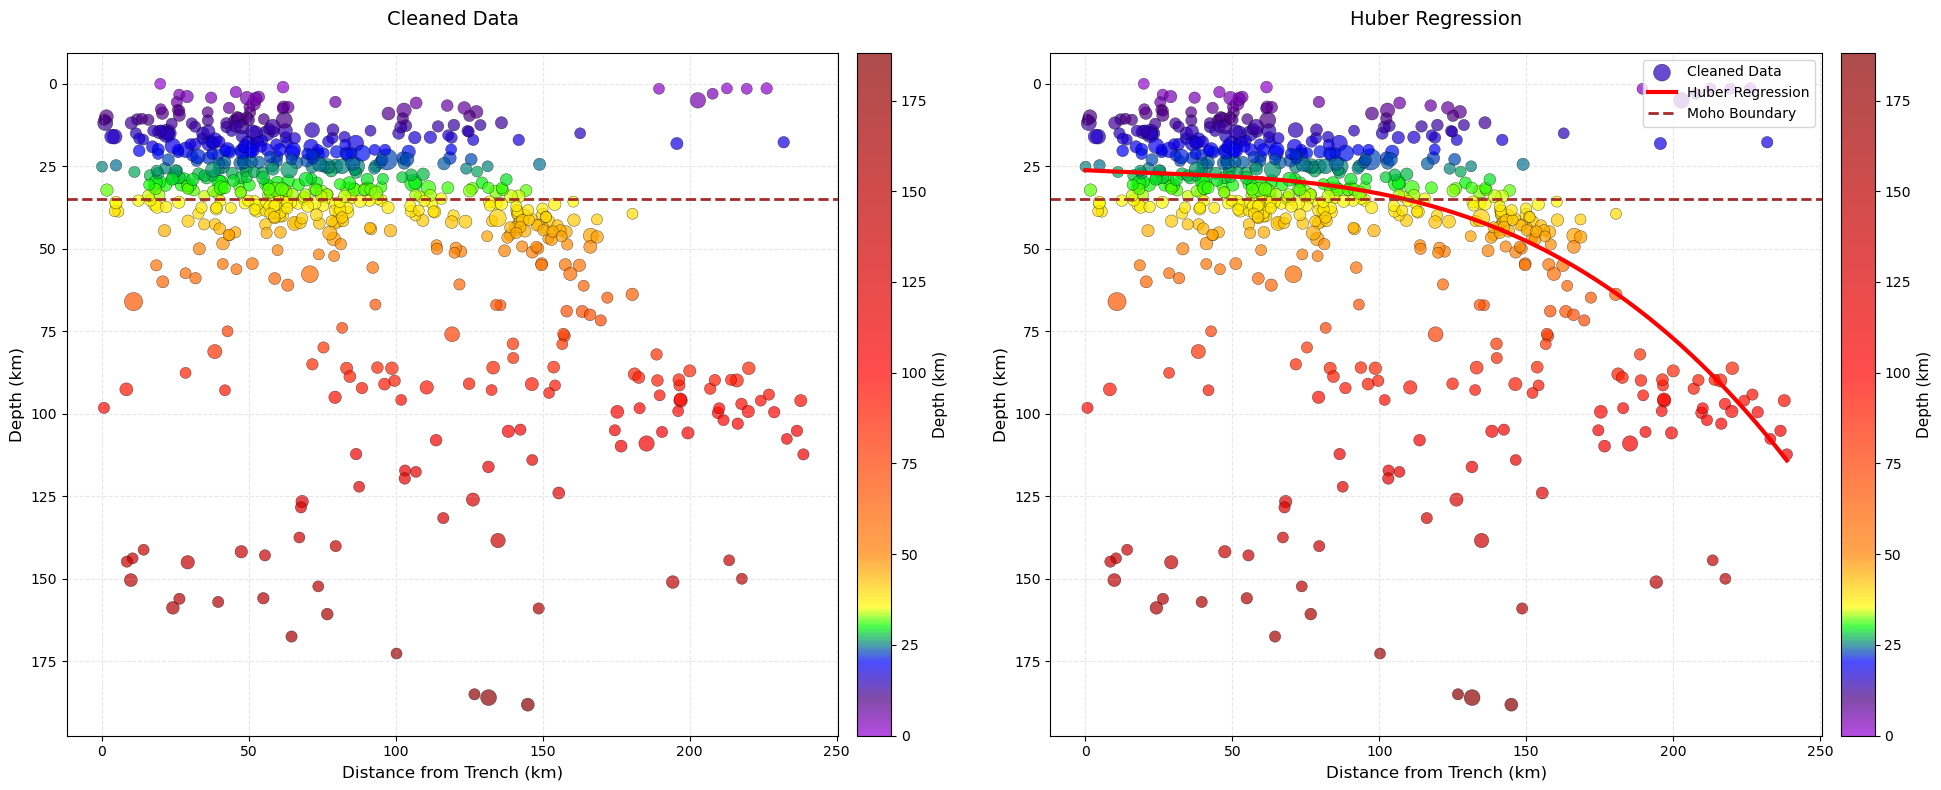

In [16]:
# 1. Clean data
depth_distance_df_cleaned = depth_distance_df.query("depth != -35 and depth != -33 and depth != -10").copy()
X_raw = depth_distance_df_cleaned['distance'].values.reshape(-1, 1)
y_raw = depth_distance_df_cleaned['depth'].values

# 2. Pre-filtering of crustal earthquakes
def filter_crustal_earthquakes(distance, depth, max_shallow_depth, min_distance_for_filter):
    return ~((depth > max_shallow_depth) & (distance > min_distance_for_filter))

crustal_mask = filter_crustal_earthquakes(X_raw.flatten(), y_raw, max_shallow_depth=0, min_distance_for_filter=0) # Фильтрация коровых землетрясений
X_filtered = X_raw[crustal_mask]
y_filtered = y_raw[crustal_mask]

print(f"Removed {len(X_raw) - len(X_filtered)} crustal earthquakes initially")

# 3. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
mu_X, sigma_X = scaler.mean_[0], scaler.scale_[0]
y_mean, y_std = y_filtered.mean(), y_filtered.std()
y_scaled = (y_filtered - y_mean) / y_std

# 4. Polynomial transform
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Huber regression
param_grid = {'epsilon': uniform(1, 2), 'alpha': uniform(0.0001, 0.01), 'max_iter': [100, 300, 500]}
search = RandomizedSearchCV(HuberRegressor(), param_grid, n_iter=20, cv=5, random_state=42)
search.fit(X_poly, y_scaled)

model = HuberRegressor(**search.best_params_)
model.fit(X_poly, y_scaled)

# 6. Predict on smooth linspace
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 200).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = model.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 9. Plot comparison in the same style as previous plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# First plot - cleaned data
scatter1 = ax1.scatter(
    X_raw.flatten(), 
    -y_raw,  # Convert depths to positive range
    c=-y_raw,  # Color depends on depth
    cmap=cmap_depth,  # Use your color palette
    s=depth_distance_df_cleaned['mag']**2 * 3,  # Size by magnitude
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)
ax1.invert_yaxis()
ax1.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')
ax1.set_title('Cleaned Data', fontsize=14, pad=20)
ax1.set_xlabel('Distance from Trench (km)', fontsize=12)
ax1.set_ylabel('Depth (km)', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter1, ax=ax1, pad=0.02).set_label('Depth (km)', fontsize=11)

# Second plot - with regression
scatter2 = ax2.scatter(
    X_filtered.flatten(), 
    -y_filtered,  # Convert depths to positive range
    c=-y_filtered,  # Color depends on depth
    cmap=cmap_depth,  # Use your color palette
    s=depth_distance_df_cleaned.loc[crustal_mask, 'mag']**2 * 3,  # Size by magnitude for filtered data
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    label='Cleaned Data'
)
# Regression line
ax2.plot(X_fit.flatten(), -y_fit, color='red', linewidth=3, label='Huber Regression')  # Convert depths
ax2.invert_yaxis()
ax2.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')
ax2.set_title('Huber Regression', fontsize=14, pad=20)
ax2.set_xlabel('Distance from Trench (km)', fontsize=12)
ax2.set_ylabel('Depth (km)', fontsize=12)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', frameon=True, fontsize=10)
plt.colorbar(scatter2, ax=ax2, pad=0.02).set_label('Depth (km)', fontsize=11)

plt.tight_layout()
plt.show()

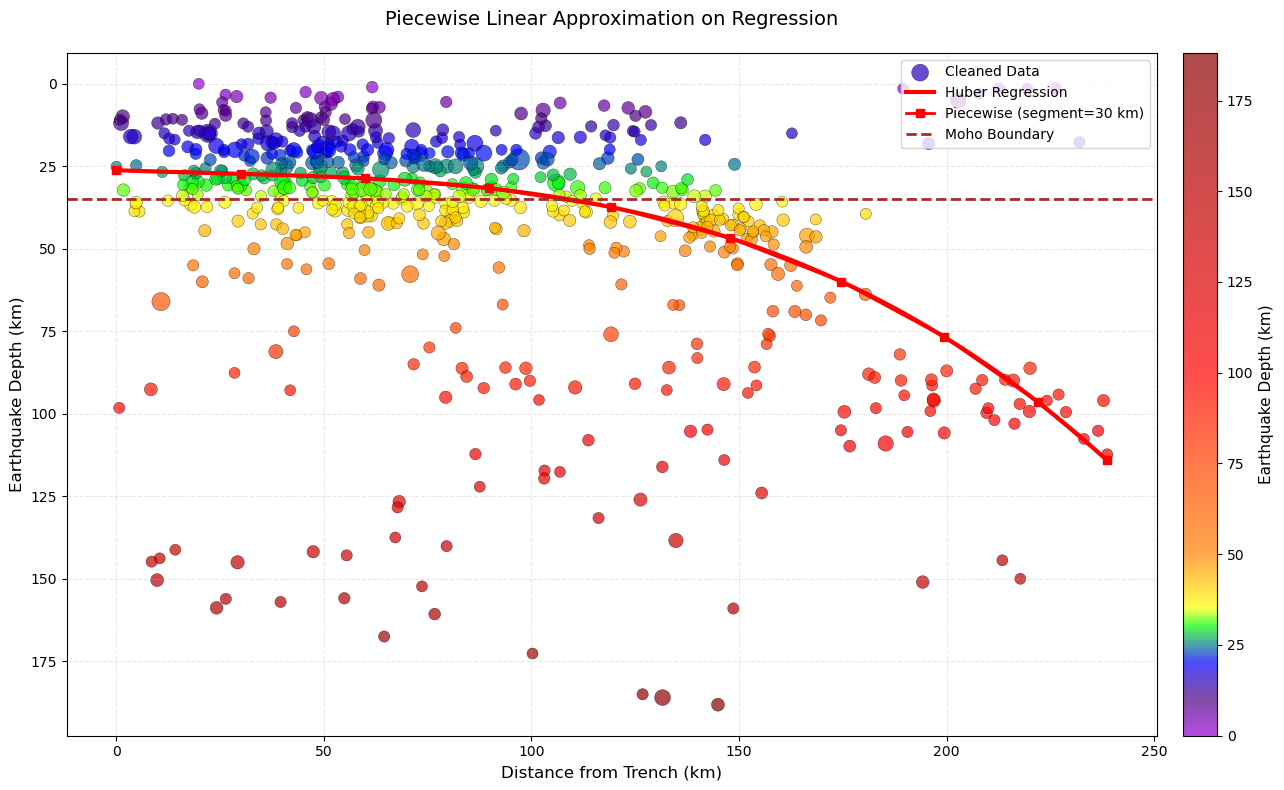

Angles between segments (degrees):
Segment 1: -2.08°
Segment 2: -2.69°
Segment 3: -5.71°
Segment 4: -11.01°
Segment 5: -18.12°
Segment 6: -26.16°
Segment 7: -34.10°
Segment 8: -41.20°
Segment 9: -46.65°


In [17]:
# 1. Prepare smooth curve from regression
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = model.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 2. Piecewise approximation works on X_fit and y_fit in original scale
X_appr = X_fit.flatten()
y_appr = y_fit.flatten()

# 3. Euclidean distance in (X, Y) plane
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# 4. Piecewise approximation function
def piecewise_approximation(X_appr, y_appr, segment_length):
    nodes = [(X_appr[0], y_appr[0])]
    total_distance = 0.0
    current_node = np.array(nodes[0])

    for i in range(1, len(X_appr)):
        next_point = np.array([X_appr[i], y_appr[i]])
        dist = euclidean_distance(current_node, next_point)

        while total_distance + dist >= segment_length:
            ratio = (segment_length - total_distance) / dist
            new_node = current_node + ratio * (next_point - current_node)
            nodes.append(tuple(new_node))
            current_node = new_node
            total_distance = 0.0
            dist = euclidean_distance(current_node, next_point)

        total_distance += dist
        current_node = next_point

    nodes.append((X_appr[-1], y_appr[-1]))

    hx, hy = zip(*nodes)
    angles = [np.arctan2(hy[i+1] - hy[i], hx[i+1] - hx[i]) for i in range(len(hx)-1)]
    return hx, hy, angles

# 5. Apply piecewise approximation
segment_length = 30  # km
hx, hy, angles = piecewise_approximation(X_appr, y_appr, segment_length)

# 6. Plot in the same style as previous plots
plt.figure(figsize=(14, 8))

# Scatter plot with color coding by depth and same size as other plots
scatter = plt.scatter(
    X_filtered.flatten(), 
    -y_filtered,  # Convert depths to positive range
    c=-y_filtered,  # Color depends on depth
    cmap=cmap_depth,  # Use your color palette
    s=depth_distance_df_cleaned.loc[crustal_mask, 'mag']**2 * 3,  # Same size formula as other plots
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    label='Cleaned Data'
)

# Regression line
plt.plot(X_fit.flatten(), -y_fit, color='red', linewidth=3, label='Huber Regression')

# Piecewise approximation
plt.plot(hx, -np.array(hy), 'rs-', markersize=6, linewidth=2, label=f'Piecewise (segment={segment_length} km)')

# Moho boundary
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')

# Styling
ax = plt.gca()
ax.invert_yaxis()
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Earthquake Depth (km)', fontsize=12)
plt.title('Piecewise Linear Approximation on Regression', fontsize=14, pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper right', frameon=True, fontsize=10)

# Colorbar
plt.colorbar(scatter, pad=0.02).set_label('Earthquake Depth (km)', fontsize=11)

plt.tight_layout()
plt.show()

# 7. Print angles
print("Angles between segments (degrees):")
for idx, angle in enumerate(angles):
    print(f"Segment {idx+1}: {np.degrees(angle):.2f}°")

Лучшие параметры: {'alpha': np.float64(0.006576901205413624), 'epsilon': np.float64(1.0010407539906316), 'max_iter': 500}


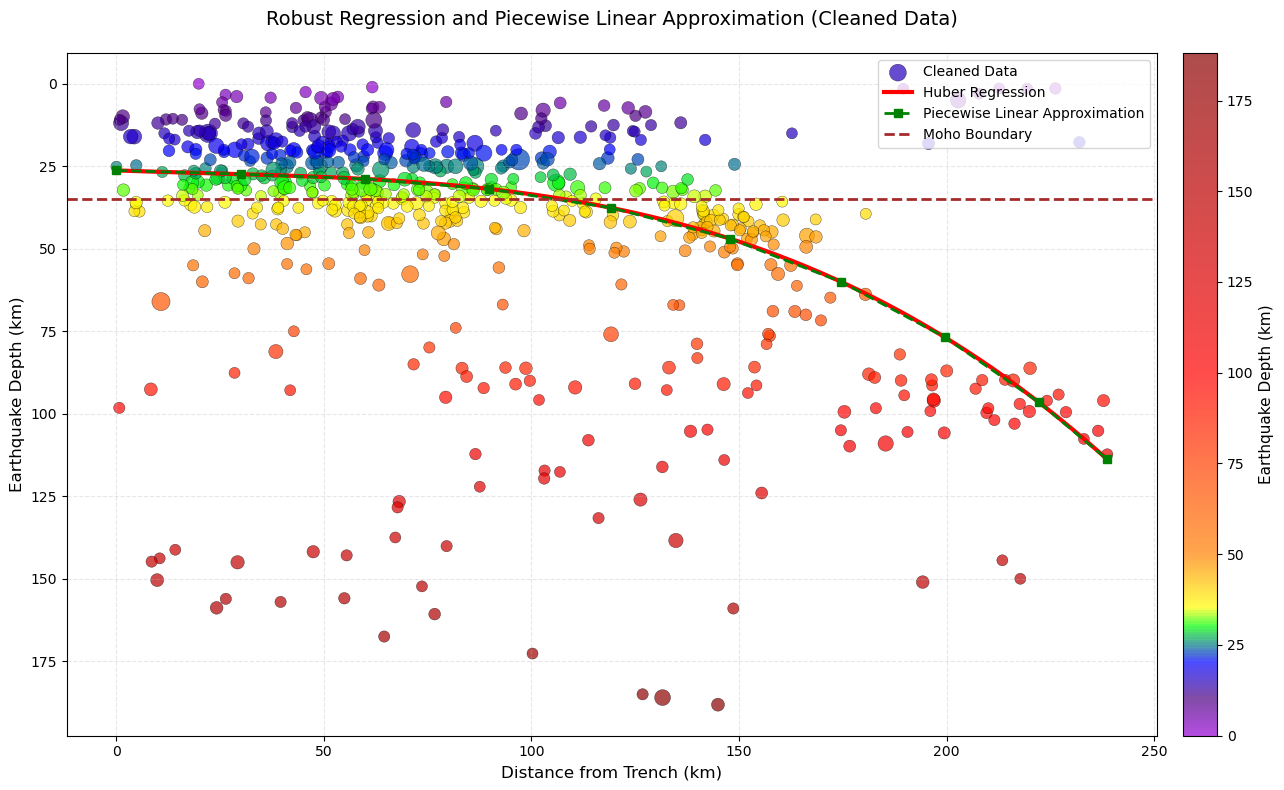

Углы сегментов (в градусах):
Сегмент 1: -2.16°
Сегмент 2: -2.78°
Сегмент 3: -5.79°
Сегмент 4: -11.04°
Сегмент 5: -18.07°
Сегмент 6: -26.04°
Сегмент 7: -33.93°
Сегмент 8: -41.00°
Сегмент 9: -46.42°


In [18]:
# 4. Полиномиальные признаки
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Обучение робастной регрессии с подбором параметров
param_distributions_huber = {'epsilon': uniform(1.0, 2.0), 'alpha': uniform(0.0001, 0.01), 'max_iter': [100, 200, 300, 400, 500]}
huber = HuberRegressor()
search = RandomizedSearchCV(huber, param_distributions_huber, n_iter=100, cv=5, random_state=42)
search.fit(X_poly, y_scaled)

huber_best = HuberRegressor(**search.best_params_)
huber_best.fit(X_poly, y_scaled)

print("Лучшие параметры:", search.best_params_)

# 6. Предсказания на сглаженном ряду
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = huber_best.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 7. Кусочно-линейная аппроксимация по предсказанной кривой

segment_length = 30
hx, hy, angles = piecewise_approximation(X_fit.flatten(), y_fit.flatten(), segment_length)

# 8. График модели и кусочно-линейной аппроксимации in the same style as previous plots
plt.figure(figsize=(14, 8))

# Scatter plot with color coding by depth
scatter = plt.scatter(
    X_filtered.flatten(), 
    -y_filtered,  # Convert depths to positive range
    c=-y_filtered,  # Color depends on depth
    cmap=cmap_depth,  # Use your color palette
    s=depth_distance_df_cleaned.loc[crustal_mask, 'mag']**2 * 3,  # Same size formula as other plots
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    label='Cleaned Data'
)

# Regression line
plt.plot(X_fit.flatten(), -y_fit, color='red', linewidth=3, label='Huber Regression')

# Piecewise approximation
plt.plot(hx, -np.array(hy), 'gs--', markersize=6, linewidth=2, label='Piecewise Linear Approximation')

# Moho boundary
plt.axhline(y=35, color='brown', linestyle='--', linewidth=2, label='Moho Boundary')

# Styling
ax = plt.gca()
ax.invert_yaxis()
plt.xlabel('Distance from Trench (km)', fontsize=12)
plt.ylabel('Earthquake Depth (km)', fontsize=12)
plt.title('Robust Regression and Piecewise Linear Approximation (Cleaned Data)', fontsize=14, pad=20)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper right', frameon=True, fontsize=10)

# Colorbar
plt.colorbar(scatter, pad=0.02).set_label('Earthquake Depth (km)', fontsize=11)

plt.tight_layout()
plt.show()

# 9. Печать углов сегментов
print("Углы сегментов (в градусах):")
for idx, angle in enumerate(angles):
    print(f"Сегмент {idx+1}: {np.degrees(angle):.2f}°")